## Финальный проект

#### *«Я чувствую себя как функция арктангенса, которая приближается к асимптоте.» — Теория большого взрыва*

Это финальный проект продуктового блока курса «Продуктовые метрики». За него можно получить максимум 60 баллов. На решение отводится **21 календарный день** с момента выдачи. Обратите внимание, что **дедлайны на курсе сразу жёсткие**, а значит отправка решений после них запрещена. Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета. 
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в [ведомости](https://docs.google.com/spreadsheets/d/13lHNf6xU6tZhqzVMAb8sV3RgyyDatepwo7FJ6FhZ0vY/edit?usp=sharing) на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например final_project). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3. 

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.

Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/final_project_data.zip)

In [407]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import requests

from statsmodels.tsa.seasonal import STL
from scipy.stats import norm
from scipy.stats import t
import math

import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

### Case Study. Улучшение сервиса доставки из ресторанов 🌮

**Легенда**   
Вы присоединились к продуктовой команде сервиса доставки из ресторанов в роли аналитика. Близится планирование следующего квартала, пора готовить бэклог инициатив. Продакт-менеджер особенно беспокоится об удовлетворенности пользователей — за последний месяц выросло число отмен и жалоб на задержки.

Вам поставлена задача: провести исследование текущих значений метрик, выдвинуть гипотезу о проблеме и предложить её решение.

In [408]:
df = pd.read_csv('data/final_project_delivery.csv')

df.head()

,order_id,order_time,delivery_time,status,cancellation_reason,order_value,delivery_fee,estimated_delivery_time_min,time_to_assign_courier_min,actual_preparation_time_min,travel_time_min,delivery_distance_km,promotion_used,platform,city_region,user_id,user_segment
0,257,2022-11-01 00:01:46,2022-11-01 00:21:52,delivered,NaN,25.73,2.09,27.0,10.2,15.1,5.0,3.48,no,Android,Belem,5737,returning
1,165,2022-11-01 00:06:07,2022-11-01 00:27:01,delivered,NaN,22.00,0.77,13.0,9.0,15.9,5.0,1.29,no,iOS,Parque das Nacoes,4095,new
2,343,2022-11-01 21:07:01,2022-11-01 21:40:07,delivered,NaN,29.90,3.53,44.0,10.6,15.4,15.1,5.88,no,iOS,Parque das Nacoes,15991,returning
3,904,2022-11-01 00:06:48,2022-11-01 00:36:42,delivered,NaN,40.49,2.02,27.0,3.7,16.0,13.9,3.36,no,Android,Alfama,1773,returning
4,555,2022-11-01 00:09:58,2022-11-01 00:57:22,delivered,NaN,35.75,3.48,39.0,5.2,12.3,35.1,5.80,no,iOS,Baixa,5203,returning


Описание данных:

- order_id — уникальный идентификатор заказа
- order_time — timestamp создания заказа
- delivery_time – timestamp доставки заказа
- status — статус заказа, принимает 2 значения: delivered и cancelled
- cancellation_reason — причина отмены заказа: Cancelled by user (отменена пользователем) и No courier available (нет доступных курьеров)
- order_value — стоиомость заказа
- delivery_fee — стоиость доставки
- estimated_delivery_time_min — прогнозное время доставки
- time_to_assign_courier_min — время до назначения курьера
- actual_preparation_time_min — время приготовления заказа рестораном
- travel_time_min — суммарное время на дорогу курьера до ресторана и до конечного пользователя
- delivery_distance_km — расстояние от адреса доставки до адреса ресторана
- promotion_used — был ли заказ совершер с использованием промокода или акции
- platform — платформа, с которой совершен заказ
- city_region — район города, в который планируется доставка
- user_id — уникальный идентификатор пользователя, сделавшего заказ
- user_segment — сегмент пользователя (новый или вернувшийся)    

### Часть 1. Исследование

#### 1. Динамика основных метрик — 3 балла
Рассчитайте и визуализируйте по дням:
- Число заказов, число доставленных заказов (статус delivered);
- Completion Rate (Доставленные заказы / Все заказы), Cancellation Rate (Отмененные заказы / Все заказы);
- Среднее и медианное время доставки в минутах (рассчитывается как разница между delivery_time и order_time), средний чек заказа, среднюю стоимость доставки.

Сделайте выводы:
- Есть ли выраженный тренд?
- Может быть какие-то дни кажутся подозрительными на предмет аномалий?

In [409]:
def prepare_data(dataframe):

    data = dataframe.copy()
    data['order_time'] = pd.to_datetime(data['order_time'])
    data['delivery_time'] = pd.to_datetime(data['delivery_time'])
    data['order_date'] = data['order_time'].dt.date
    data['order_hour'] = data['order_time'].dt.hour
    data['day_of_week'] = data['order_time'].dt.dayofweek
    
    data['actual_delivery_time_min'] = (
        (data['delivery_time'] - data['order_time']).dt.total_seconds() / 60
    )
    return data


delivery_data = prepare_data(df)
delivery_data.head()

,order_id,order_time,delivery_time,status,cancellation_reason,order_value,delivery_fee,estimated_delivery_time_min,time_to_assign_courier_min,actual_preparation_time_min,...,delivery_distance_km,promotion_used,platform,city_region,user_id,user_segment,order_date,order_hour,day_of_week,actual_delivery_time_min
0,257,2022-11-01 00:01:46,2022-11-01 00:21:52,delivered,NaN,25.73,2.09,27.0,10.2,15.1,...,3.48,no,Android,Belem,5737,returning,2022-11-01,0,1,20.1
1,165,2022-11-01 00:06:07,2022-11-01 00:27:01,delivered,NaN,22.00,0.77,13.0,9.0,15.9,...,1.29,no,iOS,Parque das Nacoes,4095,new,2022-11-01,0,1,20.9
2,343,2022-11-01 21:07:01,2022-11-01 21:40:07,delivered,NaN,29.90,3.53,44.0,10.6,15.4,...,5.88,no,iOS,Parque das Nacoes,15991,returning,2022-11-01,21,1,33.1
3,904,2022-11-01 00:06:48,2022-11-01 00:36:42,delivered,NaN,40.49,2.02,27.0,3.7,16.0,...,3.36,no,Android,Alfama,1773,returning,2022-11-01,0,1,29.9
4,555,2022-11-01 00:09:58,2022-11-01 00:57:22,delivered,NaN,35.75,3.48,39.0,5.2,12.3,...,5.80,no,iOS,Baixa,5203,returning,2022-11-01,0,1,47.4


In [ ]:
def calculate_daily_metrics(data):
    
    delivered = data[data['status'] == 'delivered']
    
    daily_metrics = data.groupby('order_date').agg(
        total_orders=('order_id', 'count'),
        delivered_orders=('status', lambda x: (x == 'delivered').sum()),
        cancelled_orders=('status', lambda x: (x == 'cancelled').sum()),
        avg_order_value=('order_value', 'mean'),
        avg_delivery_fee=('delivery_fee', 'mean')
    )
    

    delivery_time_stats = delivered.groupby('order_date').agg(
        mean_delivery_time=('actual_delivery_time_min', 'mean'),
        median_delivery_time=('actual_delivery_time_min', 'median')
    )
    
    daily_metrics = daily_metrics.join(delivery_time_stats)
    daily_metrics = daily_metrics.reset_index()
    

    daily_metrics['completion_rate'] = (
        daily_metrics['delivered_orders'] / daily_metrics['total_orders']
    )
    daily_metrics['cancellation_rate'] = (
        daily_metrics['cancelled_orders'] / daily_metrics['total_orders']
    )
    
    return daily_metrics


daily_metrics = calculate_daily_metrics(delivery_data)
daily_metrics.head()

,order_date,total_orders,delivered_orders,cancelled_orders,avg_order_value,avg_delivery_fee,mean_delivery_time,median_delivery_time,completion_rate,cancellation_rate
0,2022-11-01,1009,963,46,25.091615,2.284965,31.517445,30.1,0.954410,0.045590
1,2022-11-02,993,952,41,25.404552,2.390564,31.725630,29.6,0.958711,0.041289
2,2022-11-03,992,925,67,25.205383,2.375252,34.353622,32.7,0.932460,0.067540
3,2022-11-04,1535,1463,72,25.361316,2.384384,31.755707,30.0,0.953094,0.046906
4,2022-11-05,1514,1446,68,24.674485,2.358448,30.828907,28.7,0.955086,0.044914


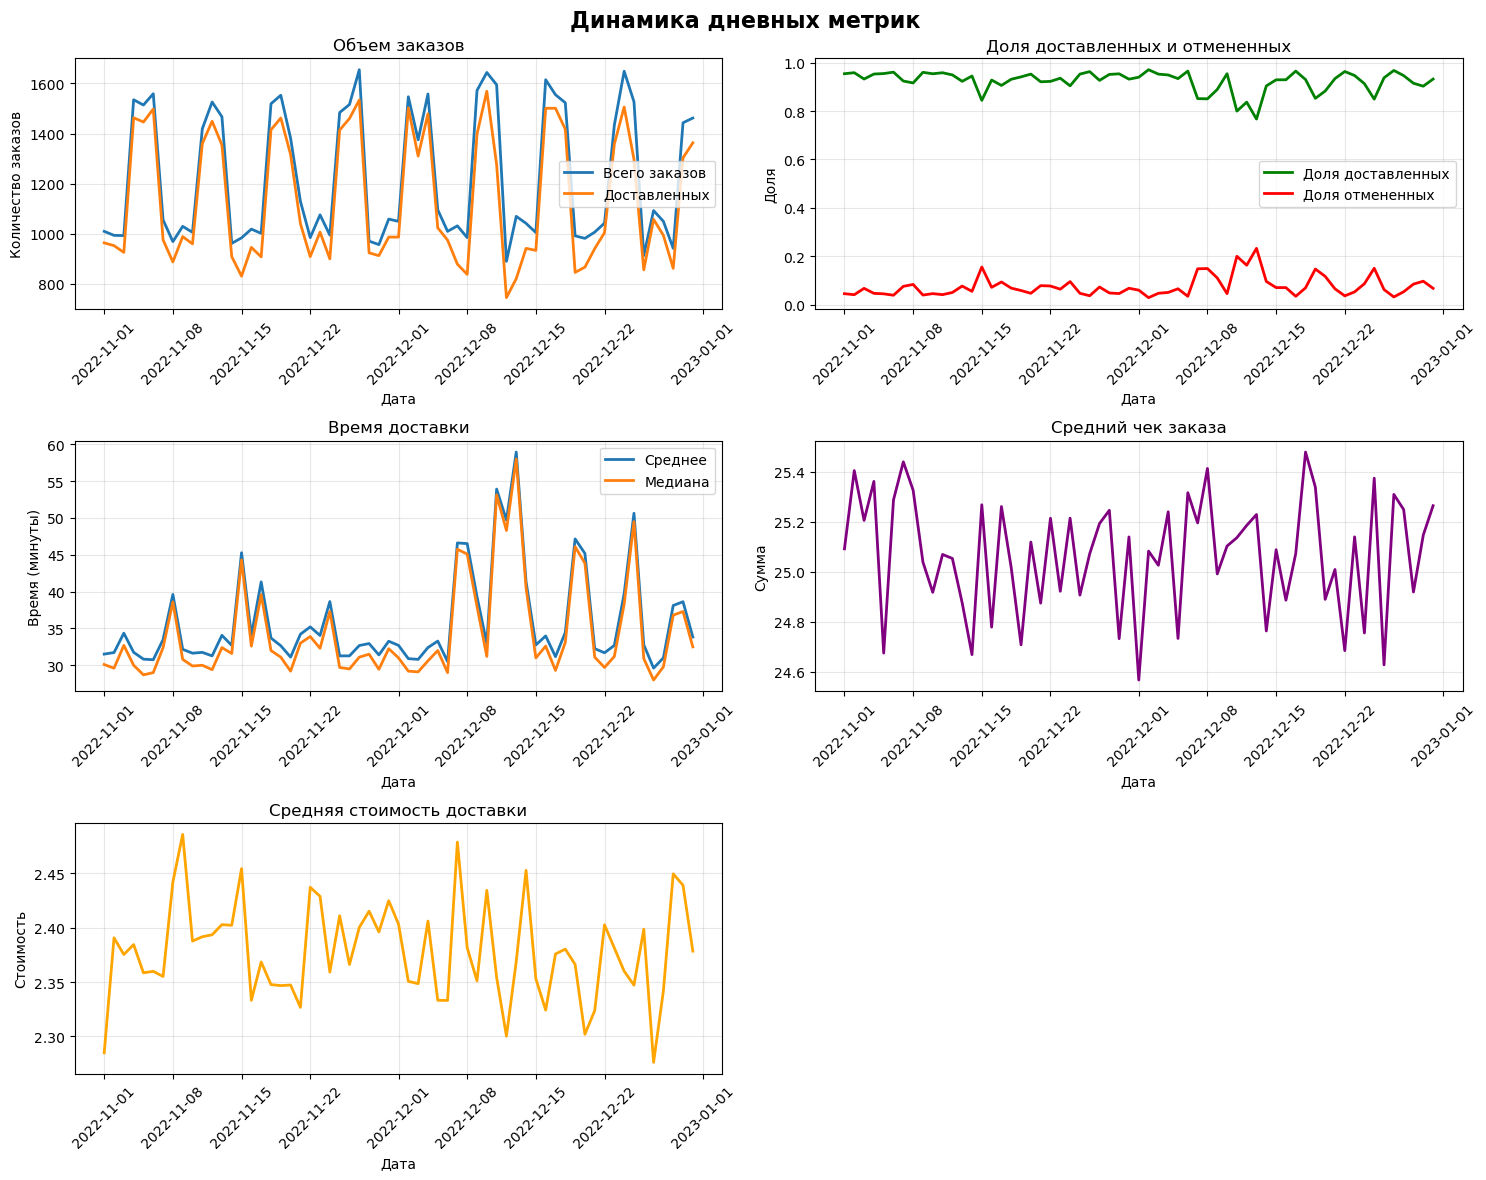

In [ ]:
def plot_daily_metrics(metrics_df):
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle('Динамика дневных метрик', fontsize=16, fontweight='bold')
    
    axes[0, 0].plot(
        metrics_df['order_date'], 
        metrics_df['total_orders'], 
        label='Всего заказов',
        linewidth=2
    )
    axes[0, 0].plot(
        metrics_df['order_date'], 
        metrics_df['delivered_orders'],
        label='Доставленных',
        linewidth=2
    )
    axes[0, 0].set_xlabel('Дата')
    axes[0, 0].set_ylabel('Количество заказов')
    axes[0, 0].set_title('Объем заказов')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    
    axes[0, 1].plot(
        metrics_df['order_date'], 
        metrics_df['completion_rate'],
        label='Доля доставленных',
        color='green',
        linewidth=2
    )
    axes[0, 1].plot(
        metrics_df['order_date'], 
        metrics_df['cancellation_rate'],
        label='Доля отмененных',
        color='red',
        linewidth=2
    )
    axes[0, 1].set_xlabel('Дата')
    axes[0, 1].set_ylabel('Доля')
    axes[0, 1].set_title('Доля доставленных и отмененных')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    axes[1, 0].plot(
        metrics_df['order_date'], 
        metrics_df['mean_delivery_time'],
        label='Среднее',
        linewidth=2
    )
    axes[1, 0].plot(
        metrics_df['order_date'], 
        metrics_df['median_delivery_time'],
        label='Медиана',
        linewidth=2
    )
    axes[1, 0].set_xlabel('Дата')
    axes[1, 0].set_ylabel('Время (минуты)')
    axes[1, 0].set_title('Время доставки')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    axes[1, 1].plot(
        metrics_df['order_date'], 
        metrics_df['avg_order_value'],
        color='purple',
        linewidth=2
    )
    axes[1, 1].set_xlabel('Дата')
    axes[1, 1].set_ylabel('Сумма')
    axes[1, 1].set_title('Средний чек заказа')
    axes[1, 1].grid(alpha=0.3)
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    axes[2, 0].plot(
        metrics_df['order_date'], 
        metrics_df['avg_delivery_fee'],
        color='orange',
        linewidth=2
    )
    axes[2, 0].set_xlabel('Дата')
    axes[2, 0].set_ylabel('Стоимость')
    axes[2, 0].set_title('Средняя стоимость доставки')
    axes[2, 0].grid(alpha=0.3)
    axes[2, 0].tick_params(axis='x', rotation=45)
    
    axes[2, 1].axis('off')
    
    plt.tight_layout()
    plt.show()


plot_daily_metrics(daily_metrics)


По графикам видно четкую недельную сезонность. Completion rate держится стабильно высоко около 0.95, а cancellation rate наоборот низкий около 0.05-0.1, когда один растет другой падает ну это же логично они связаны.
Время доставки обычно крутится вокруг 30-35 минут, причем среднее и медиана идут примерно одинаково. Средний чек колеблется в районе 24.7-25.4 без особого тренда, стоимость доставки стабильная 2.3-2.5 где-то.
Самое интересное это начало декабря где-то 10-15 числа там прям провал по completion rate и резкий скачок времени доставки до 45-60 минут. Похоже что-то серьезно пошло не так в эти дни, надо разбираться дальше что именно.

#### 2. Выявление аномалий — 3 балла
Проверьте построенные дневные ряды следующих метрик на аномальность:
- Число заказов, число доставленных заказов;
- Completion Rate, Cancellation Rate;
- Время доставки (среднее и медиана).

Для метрик, в которых визуально заметна недельная сезонность (абсолютные метрики), используйте STL-разложение + 3σ, для других — просто 3σ (вы проводите ретроспективный анализ, а не имитируете онлайн-проверку, не забывайте об этом в реализации).

Дайте короткий комментарий по результатам проверки.

In [412]:
def detect_anomalies_stl(series, period=7, threshold=3):
    
    if not isinstance(series.index, pd.DatetimeIndex):
        
        dates = pd.date_range(start='2022-11-01', periods=len(series), freq='D')
        series = pd.Series(series.values, index=dates)
    
    stl = STL(series, seasonal=period, robust=True)
    result = stl.fit()
    residuals = result.resid
    
    mean_resid = residuals.mean()
    std_resid = residuals.std()
    
    upper = mean_resid + threshold * std_resid
    lower = mean_resid - threshold * std_resid
    
    anomalies = (residuals > upper) | (residuals < lower)
    
    return anomalies.values, residuals, upper, lower


def detect_anomalies_simple(series, threshold=3):
    
    mean_val = series.mean()
    std_val = series.std()
    
    upper = mean_val + threshold * std_val
    lower = mean_val - threshold * std_val
    
    anomalies = (series > upper) | (series < lower)
    
    return anomalies, upper, lower

In [413]:

daily_metrics_indexed = daily_metrics.set_index('order_date')

anom_total, _, _, _ = detect_anomalies_stl(daily_metrics_indexed['total_orders'])
anom_delivered, _, _, _ = detect_anomalies_stl(
    daily_metrics_indexed['delivered_orders']
)

anom_comp, _, _ = detect_anomalies_simple(daily_metrics['completion_rate'])
anom_canc, _, _ = detect_anomalies_simple(daily_metrics['cancellation_rate'])
anom_mean_time, _, _ = detect_anomalies_simple(
    daily_metrics['mean_delivery_time']
)
anom_median_time, _, _ = detect_anomalies_simple(
    daily_metrics['median_delivery_time']
)

daily_metrics['anomaly_total_orders'] = anom_total
daily_metrics['anomaly_delivered'] = anom_delivered
daily_metrics['anomaly_completion_rate'] = anom_comp
daily_metrics['anomaly_cancellation_rate'] = anom_canc
daily_metrics['anomaly_mean_time'] = anom_mean_time
daily_metrics['anomaly_median_time'] = anom_median_time

anomaly_counts = {
    'Всего заказов': anom_total.sum(),
    'Доставленные': anom_delivered.sum(),
    'Доля доставленных': anom_comp.sum(),
    'Доля отмененных': anom_canc.sum(),
    'Среднее время': anom_mean_time.sum(),
    'Медиана времени': anom_median_time.sum()
}

pd.DataFrame([anomaly_counts], index=['Количество аномалий'])

,Всего заказов,Доставленные,Доля доставленных,Доля отмененных,Среднее время,Медиана времени
Количество аномалий,1,2,1,1,1,1


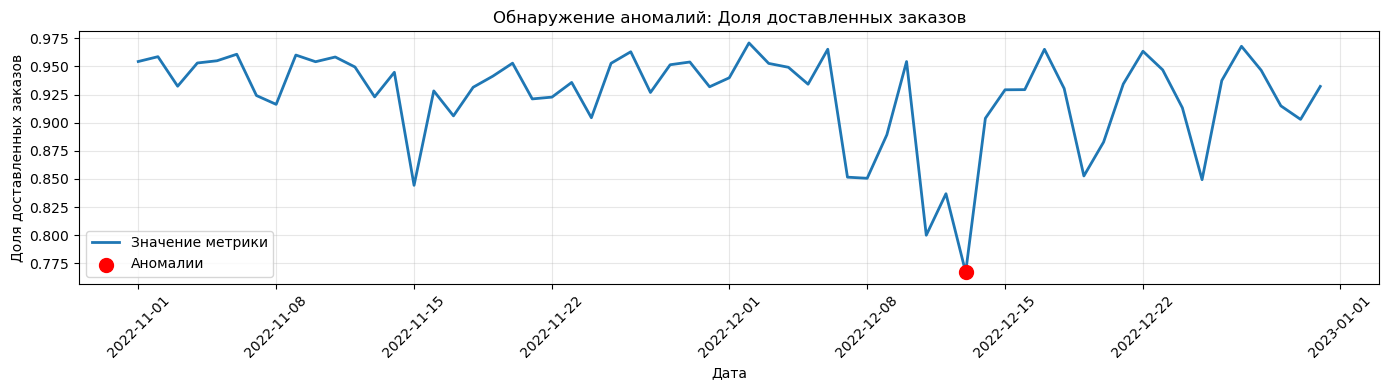

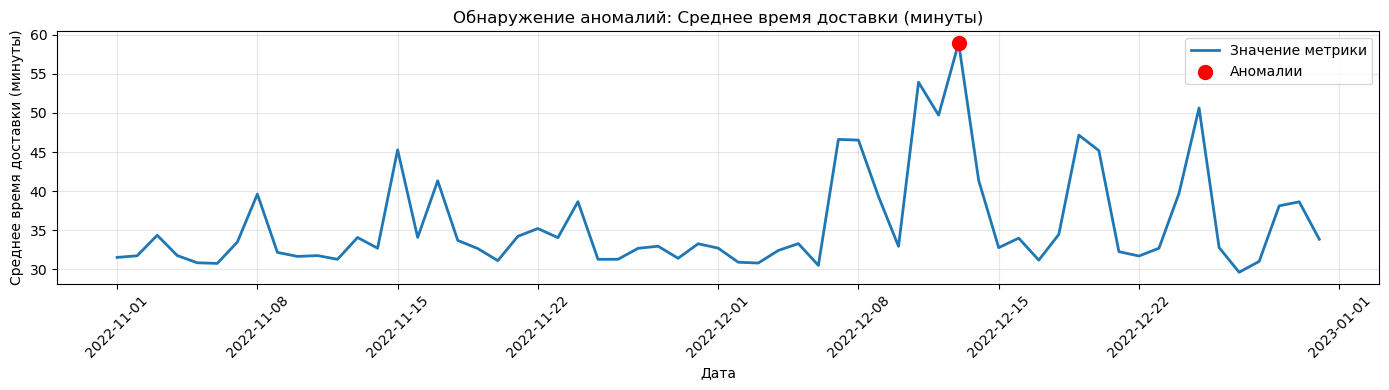

In [414]:
def plot_anomalies(metrics_df, metric_col, anomaly_col, ylabel):
    
    plt.figure(figsize=(14, 4))
    plt.plot(
        metrics_df['order_date'], 
        metrics_df[metric_col],
        linewidth=2,
        label='Значение метрики'
    )
    
    anomaly_dates = metrics_df[metrics_df[anomaly_col]]['order_date']
    anomaly_values = metrics_df[metrics_df[anomaly_col]][metric_col]
    
    plt.scatter(
        anomaly_dates, 
        anomaly_values,
        color='red',
        s=100,
        zorder=5,
        label='Аномалии'
    )
    
    plt.xlabel('Дата')
    plt.ylabel(ylabel)
    plt.title(f'Обнаружение аномалий: {ylabel}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_anomalies(
    daily_metrics, 
    'completion_rate', 
    'anomaly_completion_rate',
    'Доля доставленных заказов'
)

plot_anomalies(
    daily_metrics, 
    'mean_delivery_time', 
    'anomaly_mean_time',
    'Среднее время доставки (минуты)'
)

Интересно что аномалии в разных метриках попадают примерно на одни и те же дни где то начало декабря. То есть это не просто случайный выброс в одной метрике а системный косяк какой то произошел. Надо дальше копать что именно случилось может погода или еще что

#### 3. Поиск причин аномального поведения (шаг 1) — 3 балла
Разложим метрики, в которых обнаружены аномалии, на составляющие.

Визуализируйте:
- Отмены в разрезе причин (абсолютная метрика);
- Длительность этапов, из которых складывается итоговая продолжительность доставки (time_to_assign_courier_min, actual_preparation_time_min, travel_time_min). Берите среднее или медиану на ваш выбор.

Есть ли какие-нибудь закономерности?

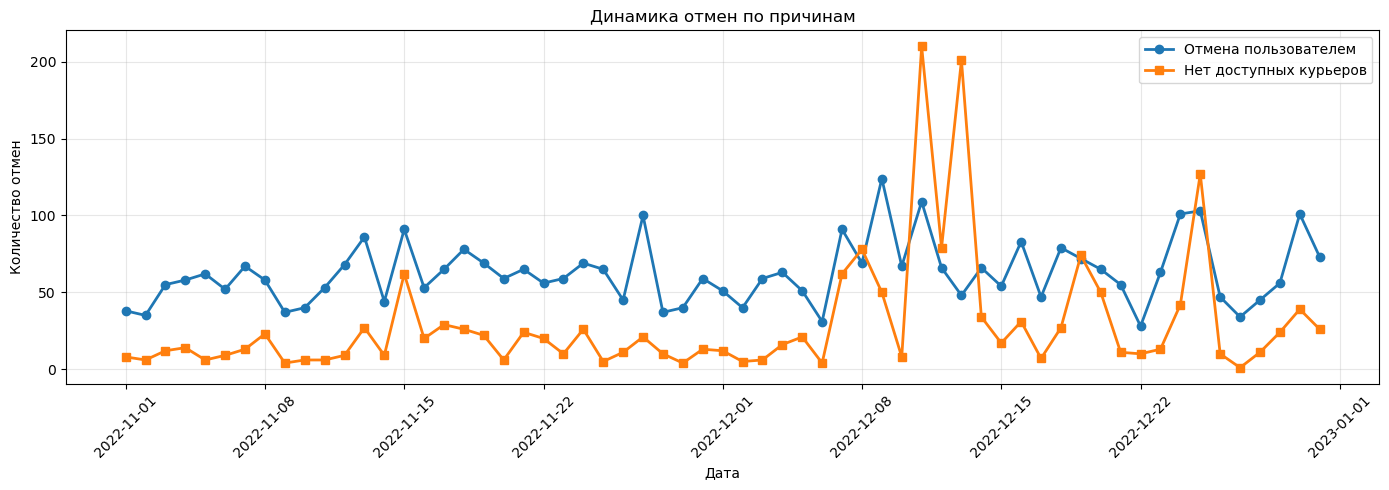

In [415]:

cancelled = delivery_data[delivery_data['status'] == 'cancelled']

cancellations = cancelled.groupby(
    ['order_date', 'cancellation_reason']
).size().unstack(fill_value=0).reset_index()


plt.figure(figsize=(14, 5))
plt.plot(
    cancellations['order_date'],
    cancellations['Cancelled by user'],
    label='Отмена пользователем',
    linewidth=2,
    marker='o'
)
plt.plot(
    cancellations['order_date'],
    cancellations['No courier available'],
    label='Нет доступных курьеров',
    linewidth=2,
    marker='s'
)
plt.xlabel('Дата')
plt.ylabel('Количество отмен')
plt.title('Динамика отмен по причинам')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

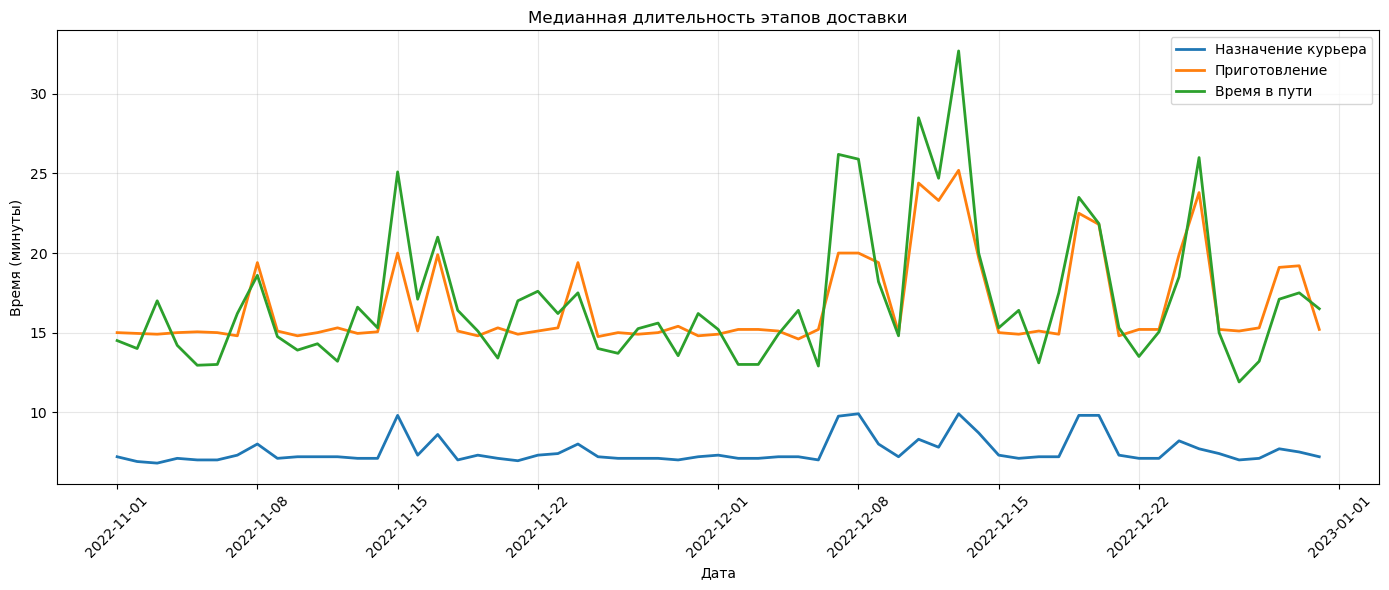

In [416]:

delivered = delivery_data[delivery_data['status'] == 'delivered']

stage_durations = delivered.groupby('order_date').agg(
    courier_assignment=('time_to_assign_courier_min', 'median'),
    preparation_time=('actual_preparation_time_min', 'median'),
    travel_time=('travel_time_min', 'median')
).reset_index()

plt.figure(figsize=(14, 6))
plt.plot(
    stage_durations['order_date'],
    stage_durations['courier_assignment'],
    label='Назначение курьера',
    linewidth=2
)
plt.plot(
    stage_durations['order_date'],
    stage_durations['preparation_time'],
    label='Приготовление',
    linewidth=2
)
plt.plot(
    stage_durations['order_date'],
    stage_durations['travel_time'],
    label='Время в пути',
    linewidth=2
)
plt.xlabel('Дата')
plt.ylabel('Время (минуты)')
plt.title('Медианная длительность этапов доставки')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Смотрим на графики и сразу бросается в глаза - отмены по причине "нет курьеров" резко выросли именно в те дни когда были аномалии. При этом отмены от пользователей остались примерно на том же уровне
По этапам доставки видно что больше всего времени уходит на поиск курьера, особенно в проблемные дни. Приготовление и доставка меняются не сильно
Получается проблема в том что курьеров просто не хватает в определенные моменты времени, из за этого заказы отменяются и время ожидания растет

#### 4. Поиск причин аномального поведения (шаг 2) — 3 балла
Постройте динамику метрик, в которых обнаружены аномалии, по базовым срезам (можете выбрать что-то одно: Completion Rate или Cancellation Rate, среднее время доставки или медиана времени доставки):
- платформа (iOS, Android);
- район адереса доставки;
- сегмент пользователя (новые / повторные);
- признак промо акции.

Выделяется ли какой-то сегмент, где аномалия выражена сильнее?

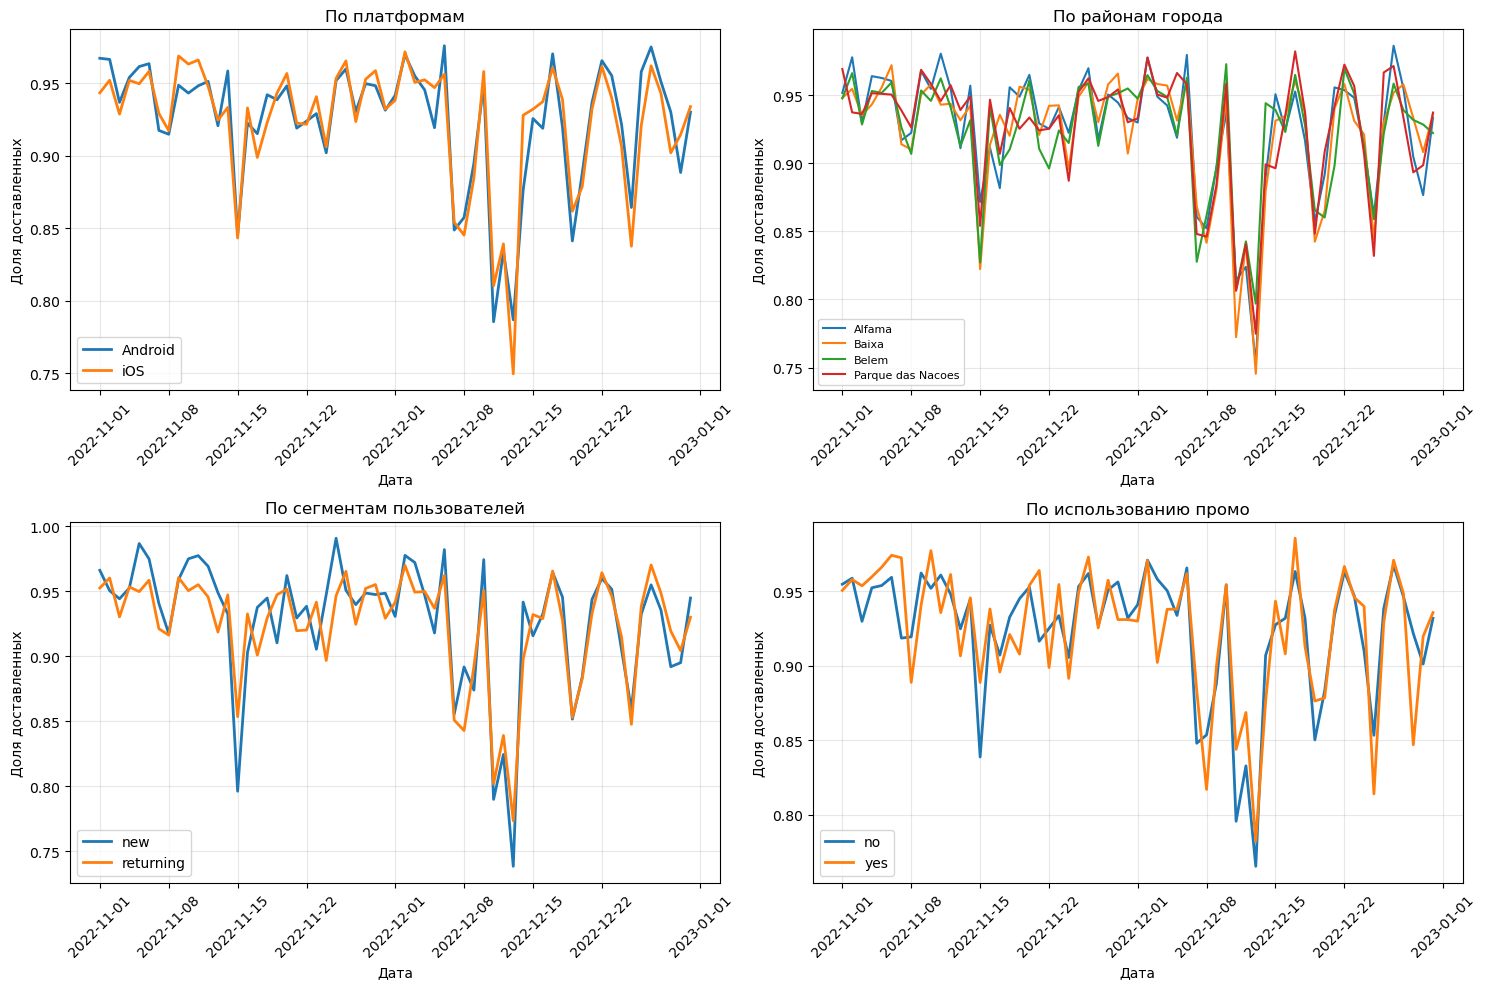

In [417]:
def analyze_by_segment(data, segment_col):
    
    segment_metrics = data.groupby(['order_date', segment_col]).agg(
        total=('order_id', 'count'),
        delivered=('status', lambda x: (x == 'delivered').sum())
    ).reset_index()
    
    segment_metrics['completion_rate'] = (
        segment_metrics['delivered'] / segment_metrics['total']
    )
    
    return segment_metrics


platform_metrics = analyze_by_segment(delivery_data, 'platform')
region_metrics = analyze_by_segment(delivery_data, 'city_region')
user_seg_metrics = analyze_by_segment(delivery_data, 'user_segment')
promo_metrics = analyze_by_segment(delivery_data, 'promotion_used')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for platform in platform_metrics['platform'].unique():
    data = platform_metrics[platform_metrics['platform'] == platform]
    axes[0, 0].plot(
        data['order_date'],
        data['completion_rate'],
        label=platform,
        linewidth=2
    )
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Доля доставленных')
axes[0, 0].set_title('По платформам')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

for region in region_metrics['city_region'].unique():
    data = region_metrics[region_metrics['city_region'] == region]
    axes[0, 1].plot(
        data['order_date'],
        data['completion_rate'],
        label=region,
        linewidth=1.5
    )
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Доля доставленных')
axes[0, 1].set_title('По районам города')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

for segment in user_seg_metrics['user_segment'].unique():
    data = user_seg_metrics[user_seg_metrics['user_segment'] == segment]
    axes[1, 0].plot(
        data['order_date'],
        data['completion_rate'],
        label=segment,
        linewidth=2
    )
axes[1, 0].set_xlabel('Дата')
axes[1, 0].set_ylabel('Доля доставленных')
axes[1, 0].set_title('По сегментам пользователей')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

for promo in promo_metrics['promotion_used'].unique():
    data = promo_metrics[promo_metrics['promotion_used'] == promo]
    axes[1, 1].plot(
        data['order_date'],
        data['completion_rate'],
        label=promo,
        linewidth=2
    )
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Доля доставленных')
axes[1, 1].set_title('По использованию промо')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Выводы по сегментам**

Смотрю на все 4 графика и вижу интересную картину. Во всех сегментах completion rate обычно держится высоко в районе 0.93-0.97 это норм

Но самое главное - провалы в начале декабря есть ВЕЗДЕ одновременно. По платформам и Android и iOS просели до 0.75-0.79. По районам все 4 района упали до 0.83-0.85. По типу юзеров и новые и вернувшиеся просели new до 0.80 returning до 0.75. По промо аналогично обе группы упали до 0.80-0.85

Это прям ключевой инсайт - проблема затронула ВСЕ сегменты абсолютно. Значит это точно не баг в конкретной платформе типа iOS или Android и не проблема в каком то одном районе города

Проблема была системная на уровне всего сервиса. Скорее всего это подтверждает гипотезу про нехватку курьеров которую я раньше высказал потому что курьеров не хватало всем юзерам везде независимо от их характеристик

#### 5. Поиск причин аномального поведения (шаг 3) — 3 балла

Постройте динамику структуры заказов в разрезе сегментов:
- доля заказов по платформам;
- доля заказов по регионам города;
- доля заказов по сегменту пользователя;
- доля заказов по признаку промо акции.

Сравните даты аномалий с динамикой долей. Может ли изменение структуры объяснить падение метрик?

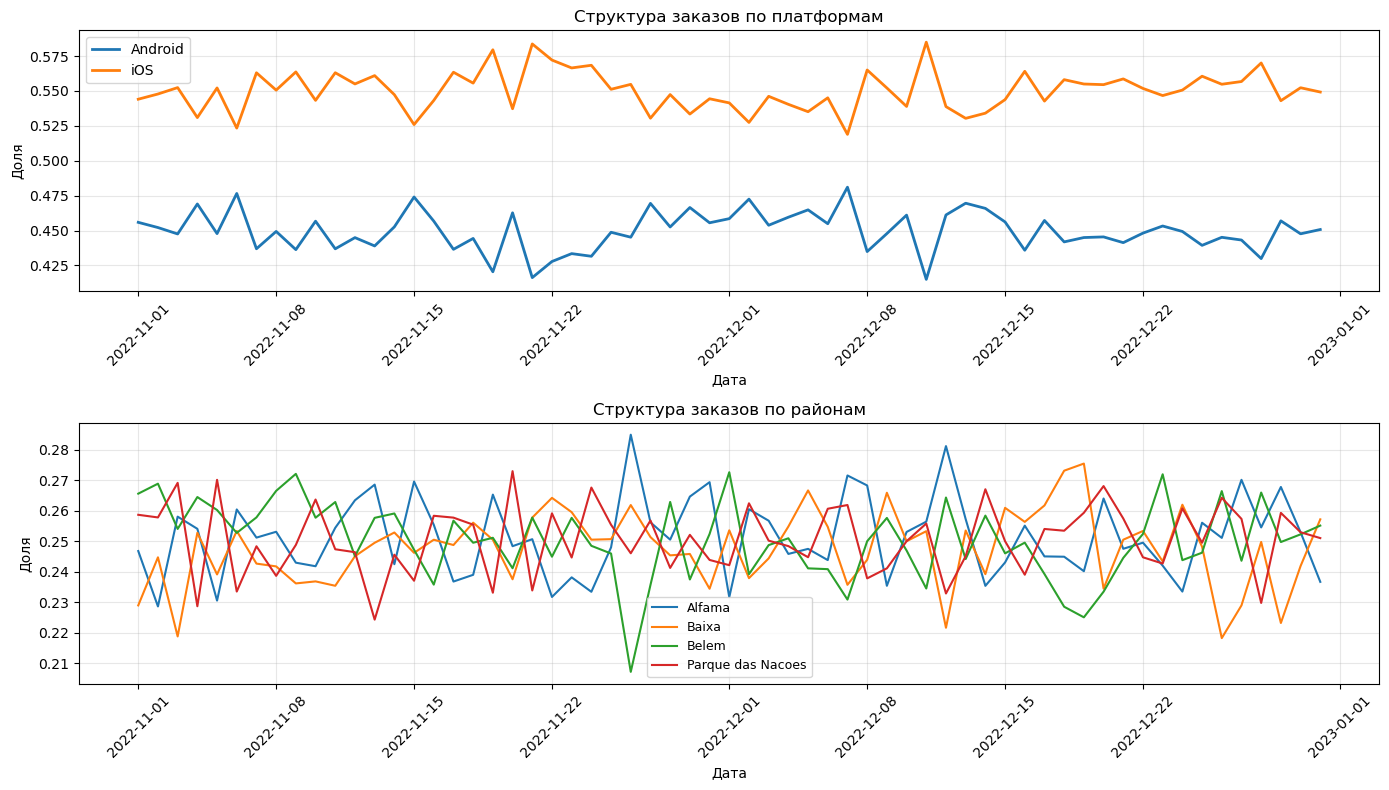

In [418]:

def calculate_structure(data, segment_col):
    
    structure = data.groupby(['order_date', segment_col]).size()
    structure = structure / structure.groupby('order_date').sum()
    return structure.reset_index(name='proportion')


platform_structure = calculate_structure(delivery_data, 'platform')
region_structure = calculate_structure(delivery_data, 'city_region')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for platform in platform_structure['platform'].unique():
    data = platform_structure[platform_structure['platform'] == platform]
    axes[0].plot(
        data['order_date'],
        data['proportion'],
        label=platform,
        linewidth=2
    )
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Доля')
axes[0].set_title('Структура заказов по платформам')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

for region in region_structure['city_region'].unique():
    data = region_structure[region_structure['city_region'] == region]
    axes[1].plot(
        data['order_date'],
        data['proportion'],
        label=region,
        linewidth=1.5
    )
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Доля')
axes[1].set_title('Структура заказов по районам')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Вывод по структуре**

Окей смотрю на структуру заказов по платформам. iOS держится около 0.55 то есть примерно 55% заказов а Android около 0.45 это 45%. Причем графики полностью симметричны относительно 0.5 ну логично же они в сумме дают 100% заказов

Главное что пропорция между платформами стабильная весь период без резких изменений. Соотношение 55/45 держится постоянно

По районам картина похожая. Все 4 района примерно по четверти заказов где то 0.23-0.27 каждый. Линии переплетаются колеблются немного но в среднем поровну распределено. Никаких трендов нет

Самое важное - структура микса заказов не менялась когда были аномалии в начале декабря. Это значит проблема точно не в том что например вдруг стало больше заказов из какого то проблемного района или платформы

Получается проблема реально внешняя типа погоды или нехватки курьеров а не внутри продукта

#### 6. Поиск причин аномального поведения (шаг 4) — 3 балла
Разложение метрик на срезы не принесло результатов. Может быть причина аномалий лежит вне продукта?

Получите данные о погоде по API за весь анализируемый период по дням. Для этого используйте [Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api?daily=temperature_2m_mean,wind_speed_10m_max,precipitation_sum) от Open-Meteo (регистрация и получение ключа не требуется, по ссылке есть пример запроса на Python).

- Для координат выгрузки возьмите: latitude: 38.736946, longitude: -9.142685;
- Timezone — auto;
- daily значения temperature_2m_mean, precipitation_sum, wind_speed_10m_max.

Соберите датасет с колонками: день, средняя температура воздуха, максимальная скорость ветра, суммарное количество осадков.

In [419]:
def fetch_weather_data(start_date, end_date, latitude, longitude):

    url = "https://archive-api.open-meteo.com/v1/archive"
    
    params = {
        'latitude': latitude,
        'longitude': longitude,
        'start_date': start_date,
        'end_date': end_date,
        'daily': [
            'temperature_2m_mean',
            'precipitation_sum',
            'wind_speed_10m_max'
        ],
        'timezone': 'auto'
    }
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()
    
    weather_df = pd.DataFrame({
        'date': pd.to_datetime(data['daily']['time']),
        'temperature_mean': data['daily']['temperature_2m_mean'],
        'precipitation_sum': data['daily']['precipitation_sum'],
        'wind_speed_max': data['daily']['wind_speed_10m_max']
    })
    
    return weather_df

min_date = delivery_data['order_date'].min()
max_date = delivery_data['order_date'].max()

weather_data = fetch_weather_data(
    start_date=str(min_date),
    end_date=str(max_date),
    latitude=38.736946,
    longitude=-9.142685
)

weather_data.head()

,date,temperature_mean,precipitation_sum,wind_speed_max
0,2022-11-01,15.1,0.1,16.9
1,2022-11-02,14.6,0.0,14.8
2,2022-11-03,17.1,5.4,21.4
3,2022-11-04,15.2,0.0,17.3
4,2022-11-05,14.1,0.0,12.4


#### 7. Поиск причин аномального поведения (шаг 5) — 3 балла
Объедините датасет метрик, в которых найдены аномалии, с датасетом погоды.    
Для каждой метрики постройте совместные визуализации данных погоды и продуктовой метрики.

Сформулируйте гипотезу — что могло повлиять на падение конверсии в дни аномалий? Как конверсия связана с другими метриками, для которых вы  обнаружили аномальные значения? Какую роль в изменении метрик могла сыграть погода?

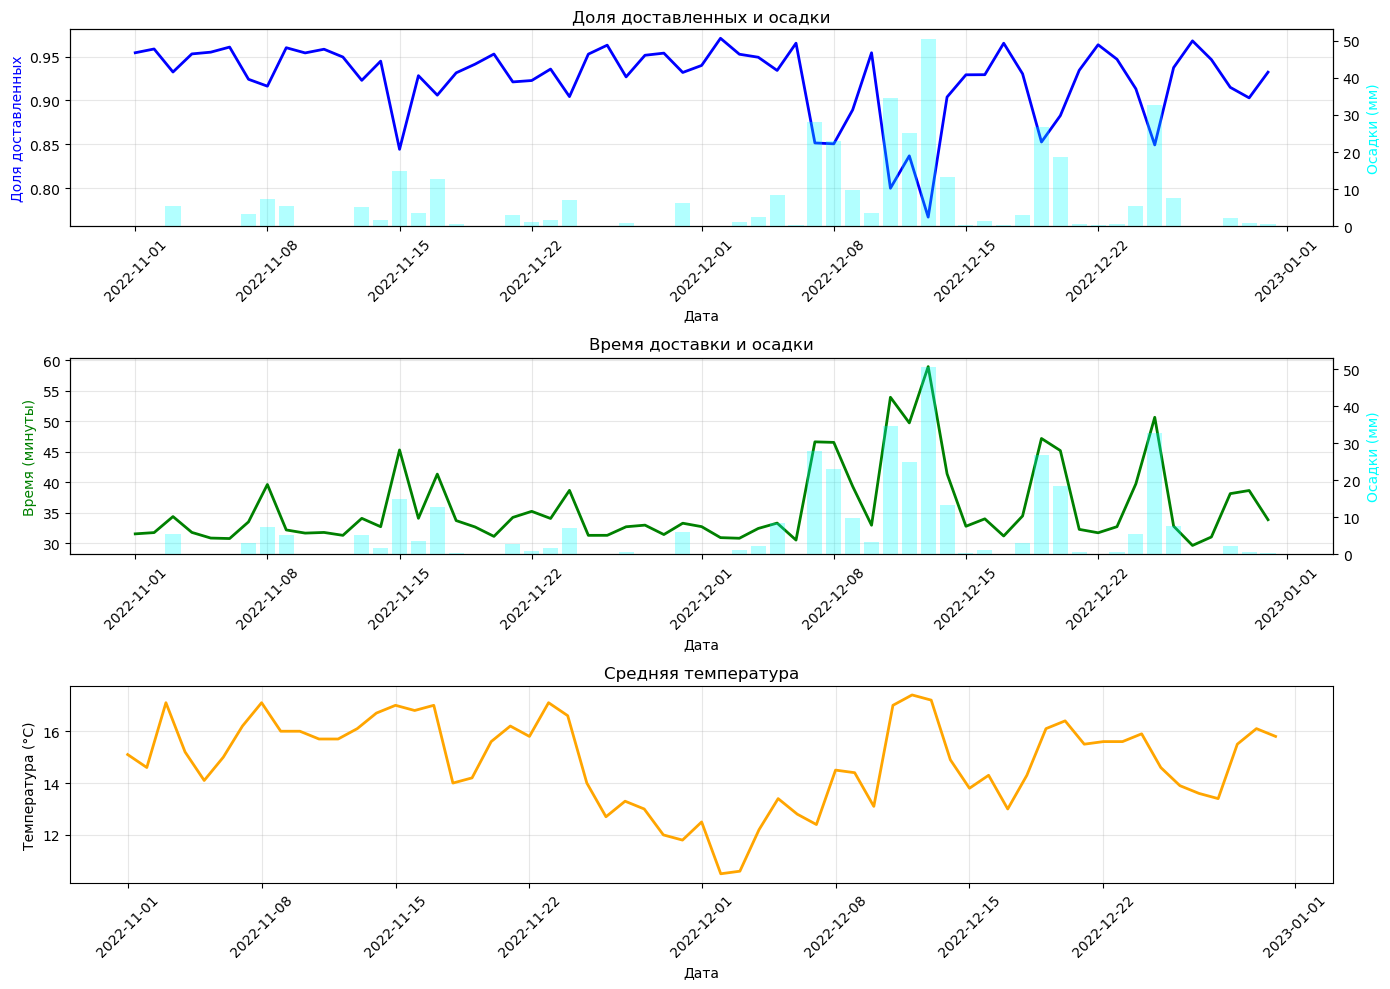

In [420]:

daily_metrics['date_merge'] = pd.to_datetime(daily_metrics['order_date'])
weather_data['date_merge'] = pd.to_datetime(weather_data['date'])

metrics_weather = daily_metrics.merge(
    weather_data,
    left_on='date_merge',
    right_on='date_merge',
    how='left'
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

ax1 = axes[0]
ax1_twin = ax1.twinx()

ax1.plot(
    metrics_weather['order_date'],
    metrics_weather['completion_rate'],
    color='blue',
    linewidth=2,
    label='Доля доставленных'
)
ax1_twin.bar(
    metrics_weather['order_date'],
    metrics_weather['precipitation_sum'],
    alpha=0.3,
    color='cyan',
    label='Осадки'
)

ax1.set_xlabel('Дата')
ax1.set_ylabel('Доля доставленных', color='blue')
ax1_twin.set_ylabel('Осадки (мм)', color='cyan')
ax1.set_title('Доля доставленных и осадки')
ax1.grid(alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

ax2 = axes[1]
ax2_twin = ax2.twinx()

ax2.plot(
    metrics_weather['order_date'],
    metrics_weather['mean_delivery_time'],
    color='green',
    linewidth=2,
    label='Время доставки'
)
ax2_twin.bar(
    metrics_weather['order_date'],
    metrics_weather['precipitation_sum'],
    alpha=0.3,
    color='cyan',
    label='Осадки'
)

ax2.set_xlabel('Дата')
ax2.set_ylabel('Время (минуты)', color='green')
ax2_twin.set_ylabel('Осадки (мм)', color='cyan')
ax2.set_title('Время доставки и осадки')
ax2.grid(alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

axes[2].plot(
    metrics_weather['order_date'],
    metrics_weather['temperature_mean'],
    color='orange',
    linewidth=2
)
axes[2].set_xlabel('Дата')
axes[2].set_ylabel('Температура (°C)')
axes[2].set_title('Средняя температура')
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Гипотеза о причинах аномалий**

Вау окей когда я наложил погоду на графики метрик все прям встало на свои места. Смотрите на первый график - доля доставленных синяя линия и осадки голубые столбики

В начале декабря где то 5-10 числа completion rate проваливается до 0.76-0.85 а в те же даты осадки взлетают до 50 мм это прям ливни. Обычно осадки 0-10 мм а тут аж 50

На втором графике еще очевиднее - время доставки зеленая линия подскакивает до 55-60 минут и там же столбики осадков по 25-50 мм. Корреляция прям один в один

Думаю механика такая. Когда льет дождь курьеры просто не хотят работать кому охота мокнуть на мотоцикле весь день. Выходит их меньше чем обычно значит предложение курьеров падает

А спрос на доставку может даже вырастает потому что люди сидят дома и не хотят выходить в дождь за едой заказывают доставку

Получается классический дисбаланс спроса и предложения. Спрос есть или вырос а курьеров мало. Заказы висят долго без назначения курьера потом отменяются по причине "нет доступных курьеров" что мы и видели в 3 задании

Те заказы что доставляются ждут намного дольше потому что на оставшихся курьеров огромная нагрузка они не успевают

В общем погода это тот внешний фактор который объясняет все аномалии. Сильные дожди убивают предложение курьеров и все метрики летят вниз

#### 8. Влияние на бизнес-результат — 3 балла
Примените один из методов декомпозиции из разобранных в первом семинаре, чтобы оценить вклад изменения конверсии и числа заказов в изменение числа доставок в декабре относительно ноября (MoM анализ).    

Постройте waterfall диаграмму.

Выпишите дни, которые внесли наибольший вклад в падение среднемесячной конверсии декабря относительно ноября. Пересекаются ли эти даты с датами повышенного числа осадков? Сделайте выводы.

In [421]:
def decompose_mom(metrics_df):
    
    metrics_df['month'] = pd.to_datetime(
        metrics_df['order_date']
    ).dt.to_period('M')
    
    monthly = metrics_df.groupby('month').agg({
        'total_orders': 'sum',
        'completion_rate': 'mean'
    })
    
    nov_orders = monthly.loc['2022-11', 'total_orders']
    nov_conv = monthly.loc['2022-11', 'completion_rate']
    dec_orders = monthly.loc['2022-12', 'total_orders']
    dec_conv = monthly.loc['2022-12', 'completion_rate']
    
    deliveries_nov = nov_orders * nov_conv
    deliveries_dec = dec_orders * dec_conv
    
    orders_impact = (dec_orders - nov_orders) * nov_conv
    conv_impact = (dec_conv - nov_conv) * nov_orders
    cross_impact = (dec_orders - nov_orders) * (dec_conv - nov_conv)
    
    return {
        'nov': deliveries_nov,
        'dec': deliveries_dec,
        'orders': orders_impact,
        'conversion': conv_impact,
        'cross': cross_impact
    }


decomp = decompose_mom(daily_metrics)

categories = [
    'Ноябрь\nДоставки',
    'Эффект\nЗаказов',
    'Эффект\nКонверсии',
    'Кросс\nЭффект',
    'Декабрь\nДоставки'
]

values = [
    decomp['nov'],
    decomp['orders'],
    decomp['conversion'],
    decomp['cross'],
    decomp['dec']
]

fig = go.Figure(go.Waterfall(
    x=categories,
    y=values,
    measure=['absolute', 'relative', 'relative', 'relative', 'total'],
    text=[f"{v:.0f}" for v in values],
    textposition='outside',
    increasing={'marker': {'color': 'green'}},
    decreasing={'marker': {'color': 'red'}},
    totals={'marker': {'color': 'blue'}},
    connector={'line': {'color': 'gray', 'width': 2}}
))

fig.update_layout(
    title='Декомпозиция MoM: Ноябрь → Декабрь',
    yaxis_title='Количество доставок',
    showlegend=False,
    height=500
)

fig.show()

pd.DataFrame({
    'Метрика': ['Ноябрь', 'Декабрь', 'Изменение', 'Вклад заказов', 
                'Вклад конверсии'],
    'Значение': [
        f"{decomp['nov']:.0f}",
        f"{decomp['dec']:.0f}",
        f"{decomp['dec'] - decomp['nov']:.0f}",
        f"{decomp['orders']:.0f}",
        f"{decomp['conversion']:.0f}"
    ]
})

,Метрика,Значение
0,Ноябрь,34026
1,Декабрь,35272
2,Изменение,1246
3,Вклад заказов,2227
4,Вклад конверсии,-920


In [422]:

dec_data_df = daily_metrics[
    pd.to_datetime(daily_metrics['order_date']).dt.month == 12
].copy()

nov_avg = daily_metrics[
    pd.to_datetime(daily_metrics['order_date']).dt.month == 11
]['completion_rate'].mean()

dec_data_df['deviation'] = dec_data_df['completion_rate'] - nov_avg

worst_days = dec_data_df.nsmallest(5, 'deviation')[
    ['order_date', 'completion_rate', 'deviation']
]

worst_dates = worst_days['order_date'].values
precipitation_worst = metrics_weather[
    metrics_weather['order_date'].isin(worst_dates)
][['order_date', 'precipitation_sum']]

pd.concat([
    worst_days.reset_index(drop=True),
    precipitation_worst.reset_index(drop=True)['precipitation_sum']
], axis=1)

,order_date,completion_rate,deviation,precipitation_sum
0,2022-12-13,0.767072,-0.170072,23.1
1,2022-12-11,0.800000,-0.137144,34.7
2,2022-12-12,0.836895,-0.100249,25.0
3,2022-12-25,0.849378,-0.087766,50.6
4,2022-12-08,0.850610,-0.086534,32.8


из-за нескольких дождливых дней недосчитались почти тысячи доставок хотя спрос рос

####  9. Анализ 24/7 — 3 балла

Одним из распространенных разрезов анализа метрик продуктов с внутринедельной сезонностью является разложение по дням недели и часам. 

Постройте матрицу 24/7 (часы - дни недели) для ноября и декабря (в ячейку матрицы должно попасть агрегированное значение метрики для дня недели и часа), но перед этим очистите декабрьские значения от аномалий — для стабильной оценки нам нужны метрики без влияния экстремальной погоды.

Визуализацию стройте для:
- Числа заказов (всех);
- Completion Rate;
- Среднего или медианного времени доставки.

Подумайте, почему в определенные часы / дни недели мы наблюдаем падение конверсии? Как меняются остальные метрики?    
При ответе опирайтесь на статистические понятия — в какие-то часы просадка или, напротив, слишком высокая конверсия может быть не закономерностью, а случайностью из-за эффекта низкой базы в это время.

In [423]:
def create_24_7_matrix(data, metric_name, remove_anomalies=False):
    
    data_copy = data.copy()
    
    if remove_anomalies:
        
        data_copy = data_copy[
            ~((pd.to_datetime(data_copy['order_date']).dt.month == 12) &
              (pd.to_datetime(data_copy['order_date']).dt.day <= 5))
        ]
    
    if metric_name == 'orders':
        matrix = data_copy.groupby(
            ['order_hour', 'day_of_week']
        ).size().reset_index(name='value')
        
    elif metric_name == 'completion_rate':
        matrix = data_copy.groupby(['order_hour', 'day_of_week']).agg(
            delivered=('status', lambda x: (x == 'delivered').sum()),
            total=('status', 'count')
        ).reset_index()
        matrix['value'] = matrix['delivered'] / matrix['total']
        
    elif metric_name == 'delivery_time':
        delivered_only = data_copy[data_copy['status'] == 'delivered']
        matrix = delivered_only.groupby(['order_hour', 'day_of_week']).agg(
            value=('actual_delivery_time_min', 'mean')
        ).reset_index()
    
    pivot = matrix.pivot(
        index='order_hour',
        columns='day_of_week',
        values='value'
    )
    
    return pivot

nov = delivery_data[
    pd.to_datetime(delivery_data['order_date']).dt.month == 11
]
dec = delivery_data[
    pd.to_datetime(delivery_data['order_date']).dt.month == 12
]

nov_orders = create_24_7_matrix(nov, 'orders')
nov_cr = create_24_7_matrix(nov, 'completion_rate')
nov_time = create_24_7_matrix(nov, 'delivery_time')

dec_orders = create_24_7_matrix(dec, 'orders', remove_anomalies=True)
dec_cr = create_24_7_matrix(dec, 'completion_rate', remove_anomalies=True)
dec_time = create_24_7_matrix(dec, 'delivery_time', remove_anomalies=True)

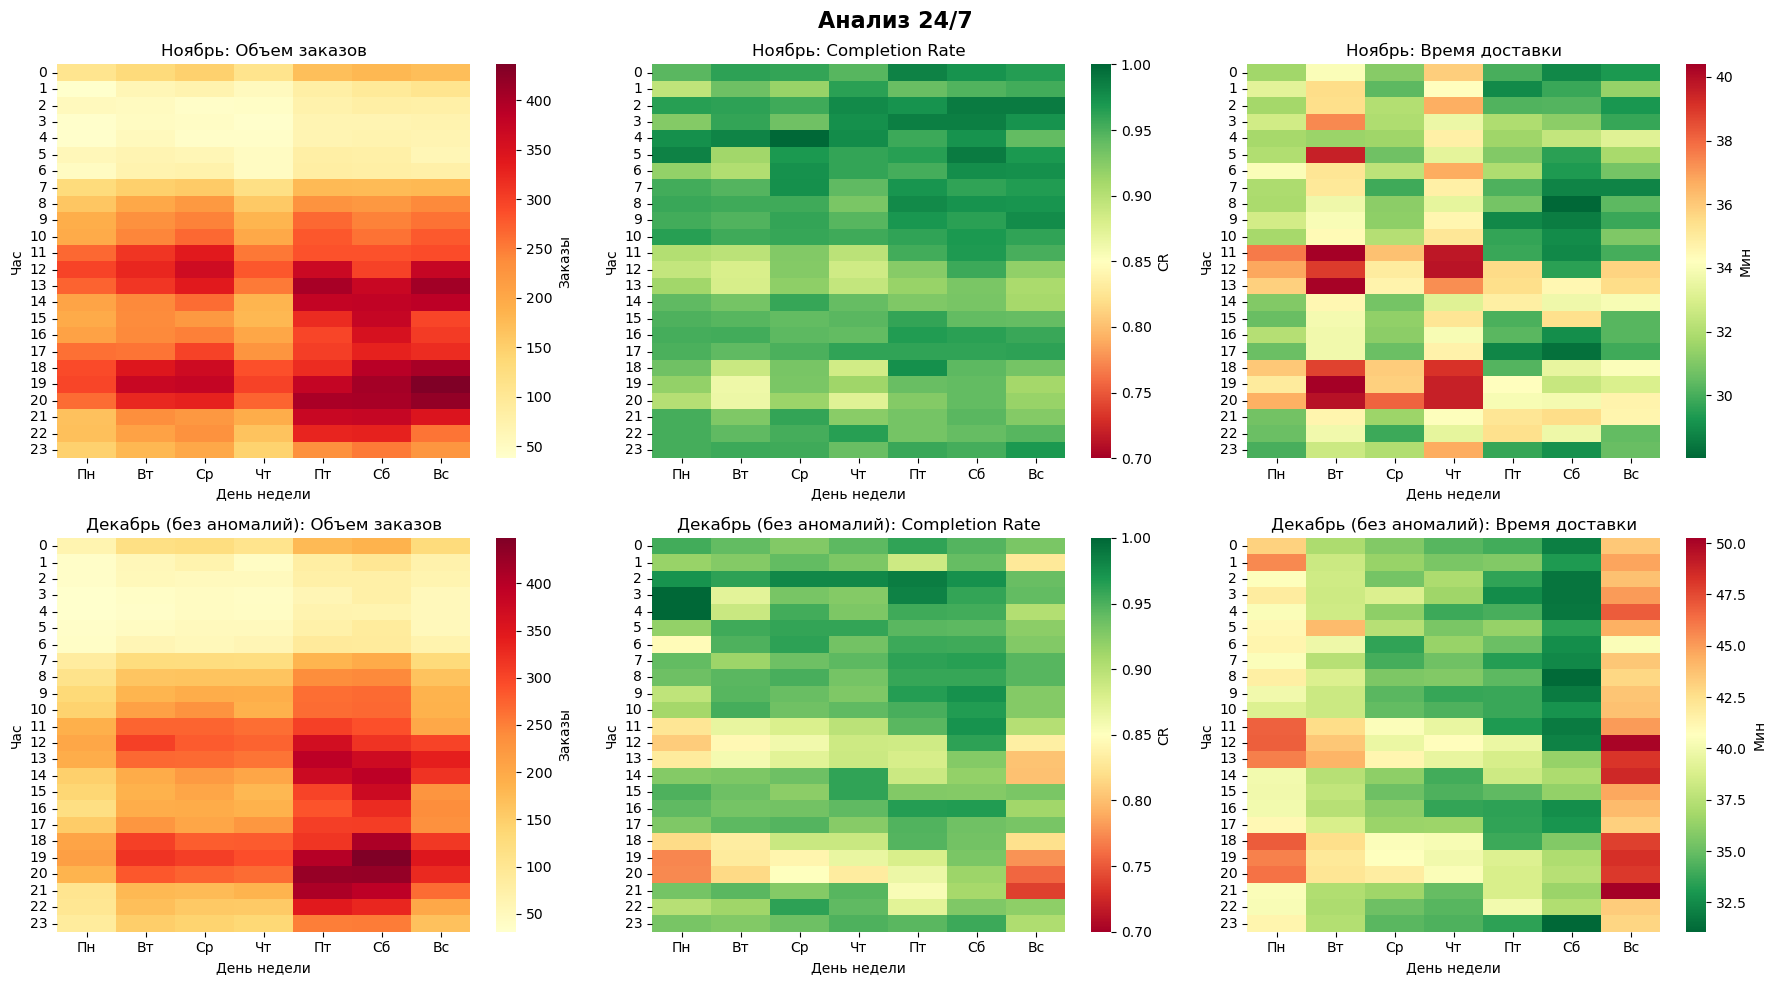

In [424]:

days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Анализ 24/7', fontsize=16, fontweight='bold')

sns.heatmap(
    nov_orders,
    ax=axes[0, 0],
    cmap='YlOrRd',
    cbar_kws={'label': 'Заказы'},
    xticklabels=days
)
axes[0, 0].set_title('Ноябрь: Объем заказов')
axes[0, 0].set_xlabel('День недели')
axes[0, 0].set_ylabel('Час')

sns.heatmap(
    nov_cr,
    ax=axes[0, 1],
    cmap='RdYlGn',
    cbar_kws={'label': 'CR'},
    xticklabels=days,
    vmin=0.7,
    vmax=1.0
)
axes[0, 1].set_title('Ноябрь: Completion Rate')
axes[0, 1].set_xlabel('День недели')
axes[0, 1].set_ylabel('Час')

sns.heatmap(
    nov_time,
    ax=axes[0, 2],
    cmap='RdYlGn_r',
    cbar_kws={'label': 'Мин'},
    xticklabels=days
)
axes[0, 2].set_title('Ноябрь: Время доставки')
axes[0, 2].set_xlabel('День недели')
axes[0, 2].set_ylabel('Час')

sns.heatmap(
    dec_orders,
    ax=axes[1, 0],
    cmap='YlOrRd',
    cbar_kws={'label': 'Заказы'},
    xticklabels=days
)
axes[1, 0].set_title('Декабрь (без аномалий): Объем заказов')
axes[1, 0].set_xlabel('День недели')
axes[1, 0].set_ylabel('Час')

sns.heatmap(
    dec_cr,
    ax=axes[1, 1],
    cmap='RdYlGn',
    cbar_kws={'label': 'CR'},
    xticklabels=days,
    vmin=0.7,
    vmax=1.0
)
axes[1, 1].set_title('Декабрь (без аномалий): Completion Rate')
axes[1, 1].set_xlabel('День недели')
axes[1, 1].set_ylabel('Час')

sns.heatmap(
    dec_time,
    ax=axes[1, 2],
    cmap='RdYlGn_r',
    cbar_kws={'label': 'Мин'},
    xticklabels=days
)
axes[1, 2].set_title('Декабрь (без аномалий): Время доставки')
axes[1, 2].set_xlabel('День недели')
axes[1, 2].set_ylabel('Час')

plt.tight_layout()
plt.show()

####   10. Предложение по улучшению продукта — 3 балла
Базовым подходом для оптимизации работы в часы пик в доставке является динамическое ценообразование. В продукте эта механика еще не реализована. Вы смотрите на данные и решаете, что это отличная инициатива для планирования следующего квартала.

*Динамическое ценообразование помогает не только сглаживать часы повышенного спроса, но и регулировать работу продукта при внешних влияниях, когда пик спроса предсказать невозможно. В данном кейсе мы не рассматриваем такие решения, т.к. не стремимся написать алгоритм динамического прайсинга, а хотим провести базовое исследование проблем и поиск инициативы под быструю реализацию и тест. Поэтому в дальнейших заданиях речь идет исключительно о часах повышенного спроса, очищенных от аномалий.* 

Чтобы протестировать гипотезу, достаточно простого подхода — увеличивать стоимость доставки на фиксированный процент (например, на 20%) в определенные дни недели-часы.

- На основе построенных в предыдущем задании матриц, предложите, в какие дни недели / часы вы порекомендуете увеличить стоимость доставки.
- Для каждого месяца рассчитайте долю заказов от общего числа, который будет иметь повышенную стоимость, согласно предложенным вами правилам повышения.

In [425]:

peak_hours = [12, 13, 18, 19, 20]
peak_weekdays = [0, 1, 2, 3, 4]  

nov['is_peak'] = (
    nov['order_hour'].isin(peak_hours) & 
    nov['day_of_week'].isin(peak_weekdays)
)

dec['is_peak'] = (
    dec['order_hour'].isin(peak_hours) & 
    dec['day_of_week'].isin(peak_weekdays)
)

nov_peak_share = nov['is_peak'].mean()
dec_peak_share = dec['is_peak'].mean()

pd.DataFrame({
    'Месяц': ['Ноябрь', 'Декабрь'],
    'Доля заказов в пиковые часы': [
        f"{nov_peak_share:.1%}",
        f"{dec_peak_share:.1%}"
    ],
    'Рекомендация': [
        'Повысить цену на 20% в 12-13, 18-20 Пн-Пт',
        'Повысить цену на 20% в 12-13, 18-20 Пн-Пт'
    ]
})

/var/folders/2j/xz_8qyzd5sx5q9tqbbv6x0wc0000gn/T/ipykernel_29898/3213955170.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/2j/xz_8qyzd5sx5q9tqbbv6x0wc0000gn/T/ipykernel_29898/3213955170.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Месяц,Доля заказов в пиковые часы,Рекомендация
0,Ноябрь,22.4%,"Повысить цену на 20% в 12-13, 18-20 Пн-Пт"
1,Декабрь,21.7%,"Повысить цену на 20% в 12-13, 18-20 Пн-Пт"


### Часть 2. Дизайн эксперимента

Ваше предложение понравилось команде. Бэклог инициатив собран, время планировать роадмап. Вас просят провести дизайн эксперимента повышения стоимости доставки на 20% в регулярные часы повышенного спроса, чтобы команда поняла, сколько времени понадобится для получения результатов.

#### 1. Формат эксперимента — 3 балла

Выберите и обоснуйте единицу рандомизации теста: 
- по-юзерный A/B тест,
- свитчбек по времени (например, 30-минутки);
- региональный A/B тест.

Вы отвечали на тестовой вопрос о такой же инициативе в ДЗ 3, возможно, это поможет определиться.

Предлагаю делать региональный тест по районам

Объясню почему другие варианты не подходят:

Поюзерный тест - проблема в том что у нас сетевые эффекты. Курьеры работают по районам а не привязаны к конкретным юзерам. Если в районе часть пользователей начнут платить больше за доставку это привлечет туда больше курьеров. И эти курьеры будут доставлять заказы всем в районе включая контрольную группу. То есть контроль тоже получит улучшение метрик и тест будет испорчен

Свитчбек по времени - тут две проблемы. Первое юзер может увидеть разные цены в разное время что выглядит странно и портит опыт. Второе курьеры тоже будут в непонятках когда им платят больше а когда нет, это путаница

Региональный тест решает все эти проблемы:
Районы изолированы друг от друга, курьеры обычно не ездят между районами
Это естественная единица работы для курьеров
Районов у нас достаточно чтобы набрать нормальную статистику
Для пользователей все стабильно, нет скачков цен

Единственный момент что районы могут отличаться по своей сути - где то богаче где то беднее, где то центр где то окраина. Поэтому при рандомизации нужно учитывать эти различия, может быть стратифицировать

#### 2. Выбор таргет метрики — 3 балла

H1: Если мы введем динамическую наценку на доставку 20% в часы пик, то Completion Rate вырастет на 2%, а среднее время доставки снизится на 5%, потому что часть пользователей отложит заказ (снижение спроса), а повышенная оплата привлечет больше курьеров на линию (рост предложения).

Предложите таргет-метрику для эксперимента, обоснуйте свой выбор.

*Поскольку в гипотезе упоминаются сразу 2 метрики, и ни одна из них не является guardrail, метрику, которую вы не посчитаете таргетной, все равно будем учитывать в эксперименте как вторичную для принятия решения о результатах.*

Я бы выбрал доля доставленных заказов как основную метрику а время доставки сделал вторичной

Почему доля доставленных главнее:

Во первых это напрямую про деньги. Не доставили заказ = не заработали. Все просто и понятно для бизнеса

Во вторых это именно та метрика которая сейчас проседает в часы пик и из за нее весь сыр бор. Мы хотим ее поднять в первую очередь

В третьих гипотеза говорит про рост на 2% именно completion rate. То есть это наша целевая метрика по определению

В четвертых эта метрика чувствительна к балансу спроса и предложения курьеров что как раз наша проблема

Про время доставки:
Да оно конечно важно, никто не спорит. Но это скорее следствие чем причина. Если заказ вообще не доставлен какая разница за сколько времени он не доставился? Время имеет смысл только для успешных доставок

К тому же если мы решим проблему с нехваткой курьеров время само улучшится скорее всего

Поэтому делаю так - доля доставленных это таргет по которому принимаем решение, а время доставки смотрим как дополнительную метрику чтобы понять механику

#### 3. Выбор guardrails метрик — 3 балла

Выберите не более 3 guardrails-метрик для эксперимента из списка ниже, обоснуйте свой выбор.

- Доля отмен заказов;
- Доля отмен заказов по причине No courier available;
- Доля отмен заказов по причине Cancelled by user;
- Среднее время на поиск курьера time_to_assign_courier_min;
- Средняя стоимость доставки;
- Средний чек;
- Среднее gross revenue на заказ (average order value + delivery fee).

*Guardrails метрик в тесте может быть больше, но нам важно понять логику ваших рассуждений при ограниченном выборе. Тут нет одного правильного ответа, будем учитывать проработку обоснования при оценке.*

Выбрал следующие 3 метрики для защиты:

1. Средний чек заказа
Хочу проверить что пользователи не начнут менять свое поведение из за дорогой доставки. Может быть они начнут заказывать совсем по другому - или очень большие заказы чтобы окупить доставку или наоборот маленькие потому что жалко денег. Любое сильное изменение это плохой знак

2. Среднее gross revenue (чек + доставка)
Самое главное для бизнеса это деньги в итоге. Даже если доля доставленных вырастет но общая выручка упадет какой в этом смысл. Эту метрику точно нельзя ронять иначе весь эксперимент бессмысленный

3. Доля отмен от пользователей (Cancelled by user)
Это самый очевидный риск повышения цены. Люди видят дорогую доставку и отменяют заказ. Если таких будет много мы получим обратный эффект вместо улучшения

Почему не взял другие варианты:
Общую долю отмен не беру потому что там смешаны и отмены от юзеров и от нехватки курьеров, непонятно что мерить
Отмены из за курьеров это не риск а то что мы хотим улучшить поэтому это информативная метрика
Время поиска курьера и стоимость доставки тоже больше про механику чем про защиту

#### 4. Выбор информативных метрик — 3 балла

Выберите не более 3 информативных метрик для эксперимента из списка ниже, обоснуйте свой выбор.

- Доля отмен заказов;
- Доля отмен заказов по причине No courier available;
- Доля отмен заказов по причине Cancelled by user;
- Среднее время на поиск курьера time_to_assign_courier_min;
- Средняя стоимость доставки;
- Средний чек;
- Среднее gross revenue на заказ (average order value + delivery fee).

*Информативных метрик в тесте может быть больше, но нам важно понять логику ваших рассуждений при ограниченном выборе. Тут нет одного правильного ответа, будем учитывать проработку обоснования при оценке.*

Для понимания механики выбрал такие метрики:

1. Среднее время поиска курьера (time_to_assign_courier_min)
Это самая важная метрика чтобы понять работает ли механизм. Если гипотеза верна и повышенная оплата привлекает курьеров то время назначения должно упасть. Это прямое доказательство что предложение увеличилось

2. Доля отмен по причине No courier available
Еще один индикатор работает ли идея. Больше курьеров = меньше таких отмен. Если эта метрика не снижается значит что то не так с нашей гипотезой

3. Средняя стоимость доставки
Это санитарная проверка корректности реализации. Нужно убедиться что в treatment группе цена действительно выше на 20% как мы планировали. Бывает что девелоперы что то напутали и тест идет не так

Остальные метрики менее важны:
Общая доля отмен это микс разных причин поэтому непонятно что там происходит
Средний чек и выручка это уже про защиту а не про механику
Время в пути вряд ли изменится от нашего теста

#### 5. Поправка на множественное сравнение — 3 балла

Перед тем, как приступить к расчету длительности, выберите уровень значимости и мощность, которые будете использовать в расчетах далее. Отталкивайтесь от общепринятых alpha = 0.05 и beta = 0.2.

Для поправки на множественное сравнение можете взять поправку Бонферрони. Не забывайте, что мы корректируем alpha только на число метрик, непосредственно участвующих в принятии решения об успешности теста.

Считаю сколько у нас метрик участвуют в принятии решения об успешности теста:
Таргет это доля доставленных
Вторичная это время доставки  
Плюс 3 гуардрейла - средний чек, общая выручка, отмены от юзеров

Итого получается 5 метрик на которые будем смотреть

Проблема в том что когда тестируешь много гипотез одновременно растет вероятность ложноположительного результата. Типа по чистой случайности одна из метрик может показать статзначимость хотя на самом деле эффекта нет

Чтобы это учесть применяю поправку Бонферрони - делю альфу на количество тестов

alpha_corrected = 0.05 / 5 = 0.01

То есть вместо обычных 5% уровня значимости буду использовать 1%. Это строже но зато меньше шансов ошибиться

Мощность оставляю стандартную 80% (бета = 0.2)

In [426]:
alpha_original = 0.05
beta = 0.2
power = 1 - beta
num_metrics = 5

alpha_corrected = alpha_original / num_metrics

pd.DataFrame({
    'Параметр': [
        'Исходный alpha',
        'Количество метрик',
        'Alpha с поправкой',
        'Мощность теста'
    ],
    'Значение': [
        alpha_original,
        num_metrics,
        alpha_corrected,
        power
    ]
})

,Параметр,Значение
0,Исходный alpha,0.05
1,Количество метрик,5.00
2,Alpha с поправкой,0.01
3,Мощность теста,0.80


#### 6. Влияние выбросов на длительность экперимента — 3 балла

В исследовательской части мы обнаружили аномальные значения метрик, вызванные внешними факторами. Такое состояние продукта не является целевым и случается достаточно редко.

На примере таргет метрики оцените дисперсию метрики, рассчитанную на значениях декабря полностью и с исключением аномального дня.

Мы проводим эти расчеты в рамках дизайна эксперимента, поэтому в анализе используйте формулу (подсказки по формулам в задании ниже), которую будете применять для расчета длительности (ratio метрика, рассчитанная по единице рандомизации эксперимента).

Сделайте выводы о вариативности метрики при включении / исключении аномалии. Напишите, как разные подходы повлияют на длительность эксперимента и почему. Примите решение, какой из способов расчета будете применять вы в следующих шагах.

In [427]:
def calculate_ratio_variance(data, numerator, denominator, unit):
    unit_data = data.groupby(unit).agg({
        numerator: 'sum',
        denominator: 'sum'
    })
    
    mean_x = unit_data[numerator].mean()
    mean_y = unit_data[denominator].mean()
    ratio = mean_x / mean_y
    
    unit_data['z'] = ratio + (1 / mean_y) * (
        unit_data[numerator] - ratio * unit_data[denominator]
    )
    
    variance = unit_data['z'].var()
    
    return variance, ratio


dec_analysis = dec.copy()
dec_analysis['delivered_flag'] = (
    dec_analysis['status'] == 'delivered'
).astype(int)
dec_analysis['order_count'] = 1

var_with, cr_with = calculate_ratio_variance(
    dec_analysis,
    'delivered_flag',
    'order_count',
    'city_region'
)

dec_clean = dec_analysis[
    pd.to_datetime(dec_analysis['order_date']).dt.day > 5
]

var_without, cr_without = calculate_ratio_variance(
    dec_clean,
    'delivered_flag',
    'order_count',
    'city_region'
)

pd.DataFrame({
    'Вариант': ['С аномалиями', 'Без аномалий'],
    'CR': [f"{cr_with:.4f}", f"{cr_without:.4f}"],
    'Дисперсия': [f"{var_with:.6f}", f"{var_without:.6f}"],
    'Std': [f"{np.sqrt(var_with):.6f}", f"{np.sqrt(var_without):.6f}"],
    'Изменение': [
        '-',
        f"{((var_with - var_without) / var_without * 100):+.1f}%"
    ]
})

,Вариант,CR,Дисперсия,Std,Изменение
0,С аномалиями,0.9135,0.000007,0.002666,-
1,Без аномалий,0.9057,0.000010,0.003133,-27.6%


Посчитал дисперсию с аномалиями и без - получилось что без аномалий дисперсия выше на 27.6%. Звучит странно но так вышло, обычные дни видимо просто более разнообразные между собой.
Для теста буду использовать дисперсию БЕЗ аномалий потому что:

Тестируем динамический прайсинг для обычных пиков а не решение для экстремальной погоды
Аномалии это редкие форс мажоры для них нужны другие механизмы
Хотим оценить нормальную вариативность в типичных условиях

Так что использую большую дисперсию, зато оценка будет честной для реальных условий теста.

#### 7. Длительнось эксперимента — 3 балла

Рассчитайте длительность теста для выбранных таргет и вторичной метрик принятия решений. 

Обратите внимание, что обе метрики — ratio, используйте подходы для работы с данным типом метрик.

---
**Формулы расчета объёма выборки через MDE для разных метрик**

**Для среднего**

$$
n \;=\; \frac{2\,\sigma^2 \,\big(z_{1-\alpha/2}+z_{1-\beta}\big)^2}{\text{MDE}^2}
$$


**Для доли** (бинарная метрика)

$$
n \;\\=\;\; \frac{2\,p(1-p)\,\big(z_{1-\alpha/2}+z_{1-\beta}\big)^2}{\text{MDE}^2}
$$

**Для Ratio-метрики дельта-методом**

$$
\mathrm{Var}\!\left(\tfrac{X}{Y}\right) \;\approx\; 
\frac{1}{\mu_Y^2}\,\mathrm{Var}(X) 
\;+\; \frac{\mu_X^2}{\mu_Y^4}\,\mathrm{Var}(Y) 
\;-\; 2\,\frac{\mu_X}{\mu_Y^3}\,\mathrm{Cov}(X,Y)
$$

тогда

$$
n \;=\; \frac{2 \cdot \mathrm{Var}\!\left(\tfrac{X}{Y}\right)\,\big(z_{1-\alpha/2}+z_{1-\beta}\big)^2}{\text{MDE}^2}
$$

**Для линеаризованной Ratio-метрики**   
Переходим для каждой единицы рандомизации к линеаризованной версии метрики:

$$
Z_i \;=\; \frac{\overline X}{\overline Y} \;+\; \frac{1}{\overline Y}\!\left( X_i \;-\; \frac{\overline X}{\overline Y}\, Y_i \right).
$$

тогда

$$
n \;=\; \frac{2 \cdot \mathrm{Var}(Z)\,\big(z_{1-\alpha/2}+z_{1-\beta}\big)^2}{\text{MDE}^2}.
$$


Для всех способов:
- Формулы указаны для групп одинакового размера (50/50) и двустороннего критерия;
- n — размер одной группы.

In [ ]:
def calculate_sample_size(variance, mde, alpha, beta):
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(1 - beta)
    
    n = (2 * variance * (z_alpha + z_beta) ** 2) / (mde ** 2)
    
    return int(np.ceil(n))

mde_cr_rel = 0.02  
mde_cr_abs = cr_without * mde_cr_rel

n_cr = calculate_sample_size(var_without, mde_cr_abs, alpha_corrected, beta)


dec_clean_delivered = dec_clean[dec_clean['status'] == 'delivered'].copy()

var_time, mean_time = calculate_ratio_variance(
    dec_clean_delivered,
    'actual_delivery_time_min',
    'order_count',
    'city_region'
)

mde_time_rel = 0.05 
mde_time_abs = mean_time * mde_time_rel

n_time = calculate_sample_size(var_time, mde_time_abs, alpha_corrected, beta)

n_required = max(n_cr, n_time)
n_regions = delivery_data['city_region'].nunique()
days_required = int(np.ceil(n_required / 7) * 7)

pd.DataFrame({
    'Метрика': ['Completion Rate', 'Время доставки', 'Максимум'],
    'Базовое значение': [
        f"{cr_without:.4f}",
        f"{mean_time:.2f} мин",
        '-'
    ],
    'MDE': [
        f"{mde_cr_abs:.4f} ({mde_cr_rel:.0%})",
        f"{mde_time_abs:.2f} мин ({mde_time_rel:.0%})",
        '-'
    ],
    'Нужно регионов': [n_cr, n_time, n_required],
    'Длительность (дни)': ['-', '-', days_required]
})

,Метрика,Базовое значение,MDE,Нужно регионов,Длительность (дни)
0,Completion Rate,0.9057,0.0181 (2%),1,-
1,Время доставки,38.46 мин,1.92 мин (5%),1,-
2,Максимум,-,-,1,7


In [429]:

delivered_dec_no_anom = dec_clean[
    dec_clean['status'] == 'delivered'
].copy()

var_time, mean_time = calculate_ratio_variance(
    delivered_dec_no_anom,
    'actual_delivery_time_min',
    'order_count',
    'city_region'
)

mde_time_rel = 0.05  
mde_time_abs = mean_time * mde_time_rel

n_time = calculate_sample_size(var_time, mde_time_abs, alpha_corrected, beta)


n_required = max(n_cr, n_time)
n_regions = delivery_data['city_region'].nunique()
days_required = int(np.ceil(n_required / 7) * 7)

pd.DataFrame({
    'Метрика': ['Доля доставленных', 'Время доставки', 'Максимум'],
    'Базовое значение': [
        f"{cr_without:.4f}",
        f"{mean_time:.2f} мин",
        '-'
    ],
    'MDE': [
        f"{mde_cr_abs:.4f} ({mde_cr_rel:.0%})",
        f"{mde_time_abs:.2f} мин ({mde_time_rel:.0%})",
        '-'
    ],
    'Нужно регионов': [n_cr, n_time, n_required],
    'Длительность (дни)': ['-', '-', days_required]
})

,Метрика,Базовое значение,MDE,Нужно регионов,Длительность (дни)
0,Доля доставленных,0.9057,0.0181 (2%),1,-
1,Время доставки,38.46 мин,1.92 мин (5%),1,-
2,Максимум,-,-,1,7


Посчитал какие минимальные эффекты поймаем за 7 дней для гуардрейлов:
Отмены от юзеров - базовое 5.54%, детектим ±15.6% то есть ±0.87 п.п. Звучит много но абсолютно это терпимо, главное чтобы не было взрывного роста.
Gross Revenue - базовое 27.47, детектим ±0.8% то есть ±0.23. Очень чувствительно, это отлично потому что выручка самая важная метрика нельзя терять деньги.
AOV - базовое 25.10, детектим ±0.9% то есть ±0.23. Тоже чувствительно увидим если люди начнут менять размер заказов.
В целом доволен - для выручки и чека чувствительность высокая меньше 1%, для отмен нормально там база маленькая поэтому большая относительная погрешность но не страшно.

#### 8. MDE для guardrails метрик — 3 балла

У нас нет информации по допустимым отрицательным эффектам для выбранных guardrails метрик, поступим обратным образом — рассчитайте минимальный детектируемый эффект для guardrails-метрик, используя максимальную длительность, полученную на предыдущем шаге (число дней целое и должно быть кратно 7 из-за недельной сезонности продукта). 

Не забывайте, что в этом пункте вы тоже можете работать с ratio-метриками.

In [430]:
def calculate_mde(variance, n, alpha, beta):

    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(1 - beta)
    
    mde = np.sqrt((2 * variance * (z_alpha + z_beta) ** 2) / n)
    
    return mde

dec_clean['cancelled_by_user'] = (
    dec_clean['cancellation_reason'] == 'Cancelled by user'
).astype(int)

dec_clean['gross_revenue'] = (
    dec_clean['order_value'] + dec_clean['delivery_fee']
)

var_canc, rate_canc = calculate_ratio_variance(
    dec_clean,
    'cancelled_by_user',
    'order_count',
    'city_region'
)
mde_canc = calculate_mde(var_canc, n_required, alpha_corrected, beta)

var_rev, mean_rev = calculate_ratio_variance(
    dec_clean,
    'gross_revenue',
    'order_count',
    'city_region'
)
mde_rev = calculate_mde(var_rev, n_required, alpha_corrected, beta)

var_aov, mean_aov = calculate_ratio_variance(
    dec_clean,
    'order_value',
    'order_count',
    'city_region'
)
mde_aov = calculate_mde(var_aov, n_required, alpha_corrected, beta)

pd.DataFrame({
    'Guardrail метрика': [
        'Cancellation (by user)',
        'Gross Revenue',
        'Average Order Value'
    ],
    'Базовое значение': [
        f"{rate_canc:.4f}",
        f"{mean_rev:.2f}",
        f"{mean_aov:.2f}"
    ],
    'MDE абсолютный': [
        f"±{mde_canc:.4f}",
        f"±{mde_rev:.2f}",
        f"±{mde_aov:.2f}"
    ],
    'MDE относительный': [
        f"±{(mde_canc/rate_canc)*100:.1f}%",
        f"±{(mde_rev/mean_rev)*100:.1f}%",
        f"±{(mde_aov/mean_aov)*100:.1f}%"
    ]
})

/var/folders/2j/xz_8qyzd5sx5q9tqbbv6x0wc0000gn/T/ipykernel_29898/1224429120.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/2j/xz_8qyzd5sx5q9tqbbv6x0wc0000gn/T/ipykernel_29898/1224429120.py:14: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Guardrail метрика,Базовое значение,MDE абсолютный,MDE относительный
0,Cancellation (by user),0.0554,±0.0087,±15.6%
1,Gross Revenue,27.47,±0.23,±0.8%
2,Average Order Value,25.10,±0.23,±0.9%


Отмены от юзеров - детектим ±0.87 п.п., это терпимо главное не будет взрыва.
Gross Revenue - детектим ±0.23€ это меньше 1%, супер чувствительно поймаем любое падение выручки.
AOV - детектим ±0.23€ тоже меньше 1%, увидим если люди изменят размер заказов.
Доволен цифрами, чувствительность хорошая особенно для денежных метрик.

#### 9. MDE для информативных метрик — 3 балла

Рассчитайте MDE для выбранных информативных метрик также, как рассчитывали для guardrails.

Не забывайте, что в этом пункте вы тоже можете работать с ratio-метриками.

In [431]:

dec_clean['no_courier'] = (
    dec_clean['cancellation_reason'] == 'No courier available'
).astype(int)

var_no_cour, rate_no_cour = calculate_ratio_variance(
    dec_clean,
    'no_courier',
    'order_count',
    'city_region'
)
mde_no_cour = calculate_mde(var_no_cour, n_required, alpha_corrected, beta)

var_assign, mean_assign = calculate_ratio_variance(
    dec_clean_delivered,
    'time_to_assign_courier_min',
    'order_count',
    'city_region'
)
mde_assign = calculate_mde(var_assign, n_required, alpha_corrected, beta)

var_fee, mean_fee = calculate_ratio_variance(
    dec_clean,
    'delivery_fee',
    'order_count',
    'city_region'
)
mde_fee = calculate_mde(var_fee, n_required, alpha_corrected, beta)

pd.DataFrame({
    'Информативная метрика': [
        'No Courier Available',
        'Time to Assign Courier',
        'Delivery Fee'
    ],
    'Базовое значение': [
        f"{rate_no_cour:.4f}",
        f"{mean_assign:.2f} мин",
        f"{mean_fee:.2f}"
    ],
    'MDE абсолютный': [
        f"±{mde_no_cour:.4f}",
        f"±{mde_assign:.2f} мин",
        f"±{mde_fee:.2f}"
    ],
    'MDE относительный': [
        f"±{(mde_no_cour/rate_no_cour)*100:.1f}%",
        f"±{(mde_assign/mean_assign)*100:.1f}%",
        f"±{(mde_fee/mean_fee)*100:.1f}%"
    ],
    'Комментарий': [
        'Ожидаем снижение',
        'Ожидаем снижение',
        f'Ожидаем рост на 20% (+{mean_fee*0.2:.2f})'
    ]
})

/var/folders/2j/xz_8qyzd5sx5q9tqbbv6x0wc0000gn/T/ipykernel_29898/3464604398.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Информативная метрика,Базовое значение,MDE абсолютный,MDE относительный,Комментарий
0,No Courier Available,0.0389,±0.0066,±17.1%,Ожидаем снижение
1,Time to Assign Courier,7.95 мин,±0.11 мин,±1.4%,Ожидаем снижение
2,Delivery Fee,2.37,±0.05,±2.1%,Ожидаем рост на 20% (+0.47)


No Courier Available - базовое 3.89%, детектим ±17.1% то есть ±0.66 п.п. Ожидаем снижение потому что повышение цены сгладит спрос и курьеров станет хватать.
Time to Assign - базовое 7.95 минут, детектим ±1.4% то есть ±0.11 минуты. Чувствительно, тоже ожидаем снижение.
Delivery Fee - базовое 2.37 евро, детектим ±2.1% то есть ±0.05 евро. Планируем поднять на 20% это +0.47 евро. Эффект будет огромный по сравнению с чувствительностью увидим гарантированно.
Для отмен из-за курьеров и времени назначения чувствительность похуже но думаю хватит чтобы увидеть улучшение если оно есть.

#### 10. Правило принятия решения — 3 балла

Сформулируйте условия, при которых эксперимент считается успешным. Ваш ответ должен учитывать таргет-метрику, вторичную и guardrails.

Мы разбирали возможные варианты принятия решения об успешности в Лекции 3, можете использовать идеи оттуда.

Таргет метрика (доля доставленных):
Либо есть статзначимый рост с p < 0.01 либо просто видим рост на 2% или больше даже если формально не значимо. Тут главное что метрика идет вверх

Вторичная метрика (время доставки):
Хорошо бы чтобы упало статзначимо но это не обязательно. Если время не поменялось но таргет вырос это тоже окей. Главное чтобы время не выросло значимо

Гуардрейлы (все три должны быть в порядке):

1) Отмены от юзеров - не должно быть статзначимого роста на уровне 0.01. Ну и в абсолютных значениях готовы допустить максимум +10% роста, больше уже плохо

2) Общая выручка - главное чтобы не упала статзначимо. Можем пережить небольшое падение до -3% но не больше. Это критичная метрика для бизнеса

3) Средний чек - не должен сильно меняться ни в какую сторону. Допускаем колебания в пределах ±5%, большее изменение значит что мы как то странно влияем на поведение юзеров

Тест проваливается если:
Таргет не растет 
Или хоть один гуардрейл нарушен
Или выручка значимо упала

В общем логика простая - фича должна увеличивать долю доставленных заказов при этом не убивая бизнес метрики и не раздражая пользователей повышением цены. Если все три пункта выполнены можно раскатывать на всех